# Credit Card Fraud Detection
## 目的
- クレジットカード不正検知の予測モデルを構築する。

## 結論

- 結論1：探索的分析の結果、PCA由来の特徴量は相関が小さく、Classによって分布が分離する特徴量（V4、V11 など）が存在した。
- 結論2：3モデル比較ではPR-AUCを重視するとRandomForestが最も良く、不正クラスの識別能力が高かった。
- 採用／不採用の判断：ベースラインとしてはRandomForestを採用候補とし、LogisticRegressionは参考値、GradientBoostingは現時点では不採用とする。



## 前提条件・制約
### 使用するデータ
本Notebookで利用するデータセットは、Kaggleより引用したものであり、ライセンス情報やデータ特性の説明は別途[README](../../datasets/credit-card-fraud/kaggle/README.md)に記載している。データセットは、、2013年9月に欧州のカード保有者がクレジットカードで行った取引であり、クレジットカード決済の慣習で「取引 = トランザクション」と称する。

データセットは、以下の特徴を持つ。
- 2日間に発生したトランザクションの集合
- トランザクション総数：284,807件
- 不正件数：492件（全体の0.172%）
- 入力変数はすべて数値で、[PCA変換](../../notes/ml/pca/pca.md)の結果
- Time（データセット内における初回取引からの経過時間）とAmount（取引金額）は、PCA変換されていない特徴量
- Classは、目的変数であり、不正の場合は"1"、それ以外は"0" 

### 前処理の方針（標準化・欠損処理など）

- 欠損値は原則ない前提だが、実行時に確認し、もし存在する場合は本Notebookでは簡易的に除外する。
- V1〜V28 はPCA由来の数値特徴量であり、木系モデルでは追加の標準化は必須ではない。
- Time と Amount はPCA変換されていないため、必要に応じて変換を検討するが、モデル学習では基本的に元の値を使用する。
- 変換やスケーリングを行う場合は、学習データでのみフィットし、検証・テストに適用してデータリークを防ぐ。

### 距離尺度・評価指標

- クラス不均衡が非常に大きいため、Accuracyだけでは性能を正しく評価しにくい（全てを正常と予測しても高いAccuracyになってしまう）。そのため、陽性クラスの識別能力に敏感なROC-AUCやPR-AUCを重視する。
  - ROC-AUCは偽陽性率まで含めた全体の識別性能、PR-AUCは不正（陽性）に対する精度と再現率に焦点を当てる。クラス不均衡が強い場合はPR-AUCの方が実感に近いことが多い。
- 混同行列は「実際の正解」と「予測結果」の組み合わせ（真陽性/偽陽性/真陰性/偽陰性）の件数を表す表で、どの誤りが多いかを把握するために確認する。ただし、閾値0.5固定だと不正検知では陽性を見逃しやすく、モデル性能を過小評価しやすいので参考値として扱う。

### 今回は扱わないこと

- 不均衡対策（アンダーサンプリング、SMOTEなど）の詳細な比較。
- コスト敏感学習や閾値最適化（業務コストを考慮した最適閾値の探索）。
- 本格的なハイパーパラメータ探索や特徴量エンジニアリング。
- 時系列性を考慮した分割（本Notebookはランダム分割とする）。



## データセットの確認
### データセットの俯瞰

まず、データセットの先頭5行をチェックする。

In [3]:
from pathlib import Path
import pandas as pd

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists():
    repo_root = repo_root.parent

csv_path = repo_root / "datasets/credit-card-fraud/kaggle/raw/creditcard.csv"
df = pd.read_csv(csv_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


次に、データセットの行数、列数を確認する。以下のコードを実行すると、284,807行、31列のデータから構成されていることが分かる。

In [4]:
print("Credit Card Fraud Datasets- rows:", df.shape[0], "columns:", df.shape[1])

Credit Card Fraud Datasets- rows: 284807 columns: 31


統計情報を確認する。特徴量"Time"を確認すると、284,807件のトランザクションが存在し、maxの値（172,792秒）から2日間のデータが存在することが分かる。
- 計算式：172,792 秒 = 2,879分52秒 = 47時間59分52秒 = 1日23時間59分52秒

In [5]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### 欠損データの有無を確認

以下の出力結果から、欠損データは存在しない。

In [6]:
null_counts = df.isna().sum()
total = null_counts.sort_values(ascending=False)
percent = (null_counts / df.isnull().count() * 100).sort_values(ascending=False)
pd.concat([total, percent], axis=1, keys=["Total", "Percent"]).transpose()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 取引金額や取引時間帯の傾向

不正決済が発生した時、取引金額に何らかの傾向があったり、時間帯が偏っている可能性がある。その一次調査として以下を確認する。
- 件数、平均、中央値、標準偏差、最小/最大、四分位点（分位点）
- 不正/正常の件数と割合
- 不正/正常別の取引金額・時間の要約統計
- 時間帯（1時間単位）ごとの不正率

In [10]:
# 不正/正常の件数と割合
df["Class"].value_counts()
df["Class"].value_counts(normalize=True)

# 不正/正常別の取引金額・時間の要約統計
df.groupby("Class")[["Amount", "Time"]].agg(["count", "mean", "median", "std", "min", "max"])

# 分位点（外れ値の把握に有用）
df[["Amount", "Time"]].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

# 時間帯（0-23時）の不正率
df["hour"] = (df["Time"] % 86400) // 3600
df.groupby("hour")["Class"].mean().sort_index()


hour
0.0     0.000780
1.0     0.002370
2.0     0.017127
3.0     0.004868
4.0     0.010412
5.0     0.003679
6.0     0.002195
7.0     0.003175
8.0     0.000876
9.0     0.001010
10.0    0.000482
11.0    0.003144
12.0    0.001102
13.0    0.001106
14.0    0.001388
15.0    0.001579
16.0    0.001337
17.0    0.001794
18.0    0.001937
19.0    0.001214
20.0    0.001074
21.0    0.000904
22.0    0.000583
23.0    0.001920
Name: Class, dtype: float64

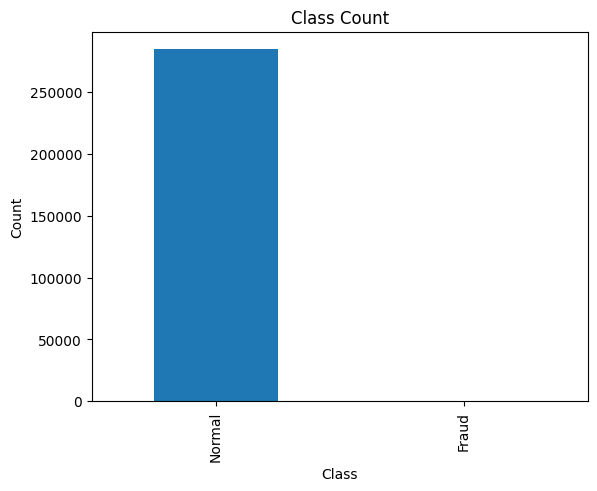

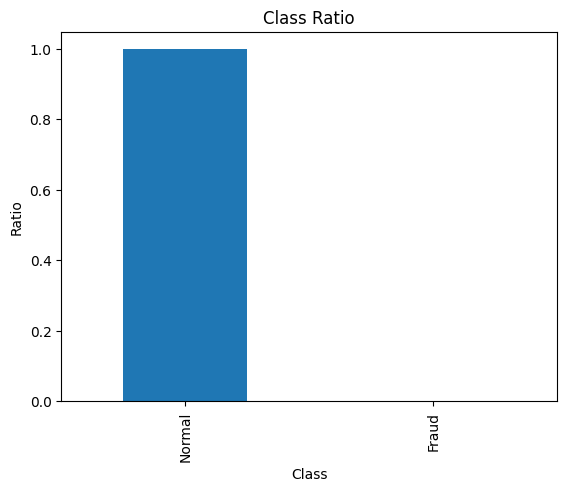

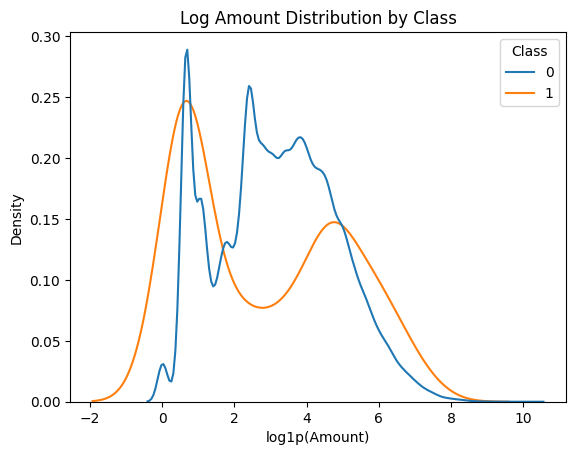

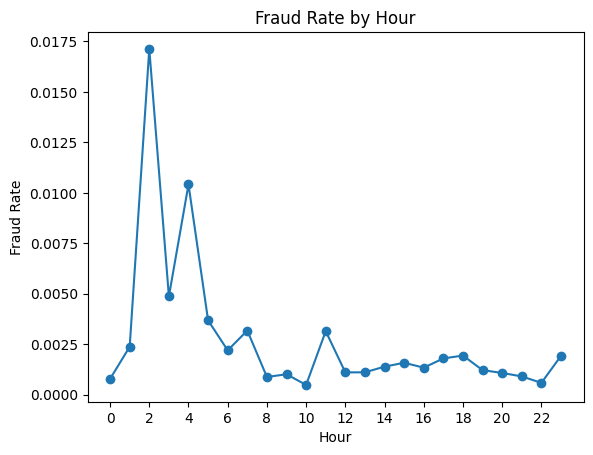

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 不正/正常の件数（棒グラフ）
ax = df["Class"].value_counts().rename(index={0: "Normal", 1: "Fraud"}).plot(kind="bar")
ax.set_title("Class Count")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
plt.show()

# 不正/正常の割合（棒グラフ）
ax = (df["Class"].value_counts(normalize=True)
      .rename(index={0: "Normal", 1: "Fraud"})
      .plot(kind="bar"))
ax.set_title("Class Ratio")
ax.set_xlabel("Class")
ax.set_ylabel("Ratio")
plt.show()

# 取引金額の分布（金額が右に長い歪んだ分布で外れ値が多いので、対数変換。高額取引を圧縮し、少額取引を拡大）
df["log_amount"] = np.log1p(df["Amount"])
sns.kdeplot(data=df, x="log_amount", hue="Class", common_norm=False)
plt.title("Log Amount Distribution by Class")
plt.xlabel("log1p(Amount)")
plt.show()

# 時間帯ごとの不正率（折れ線）
hour_rate = df.groupby("hour")["Class"].mean().sort_index()
ax = hour_rate.plot(kind="line", marker="o")
ax.set_title("Fraud Rate by Hour")
ax.set_xlabel("Hour")
ax.set_ylabel("Fraud Rate")
ax.set_xticks(range(0, 24, 2))
plt.show()


上記の結果から、以下の傾向が見られる。
- クラス比率は極端に偏っており、不正取引は全体のごく一部である（強いクラス不均衡）
- 取引金額（対数）分布では、不正取引は中〜高額側に密度が寄りやすく、正常取引とは分布形状が異なる傾向がある。
- 時間帯別の不正率は深夜〜早朝（特に2時前後）で相対的に高く、時間帯が不正に関連する可能性がある。

### 各特徴量の相関
相関を確認する理由は、(1) ほぼ同じ情報を持つ特徴量（冗長性）を見つける、(2) 多重共線性の影響を把握する、(3) どの特徴量が目的変数（Class）や他の特徴量と関係しそうか当たりを付けるためである。ここでの多重共線性とは、説明変数同士が強く相関し、回帰モデルの係数が不安定になる状態を指す。

本データの V1〜V28 は PCA によって得られた主成分のため、理論上は互いに相関が小さいはずである。そこで、Time と Amount との相関や、例外的に相関が残る特徴量がないかを確認する。具体的には、Pearson 相関係数で相関行列を可視化する。

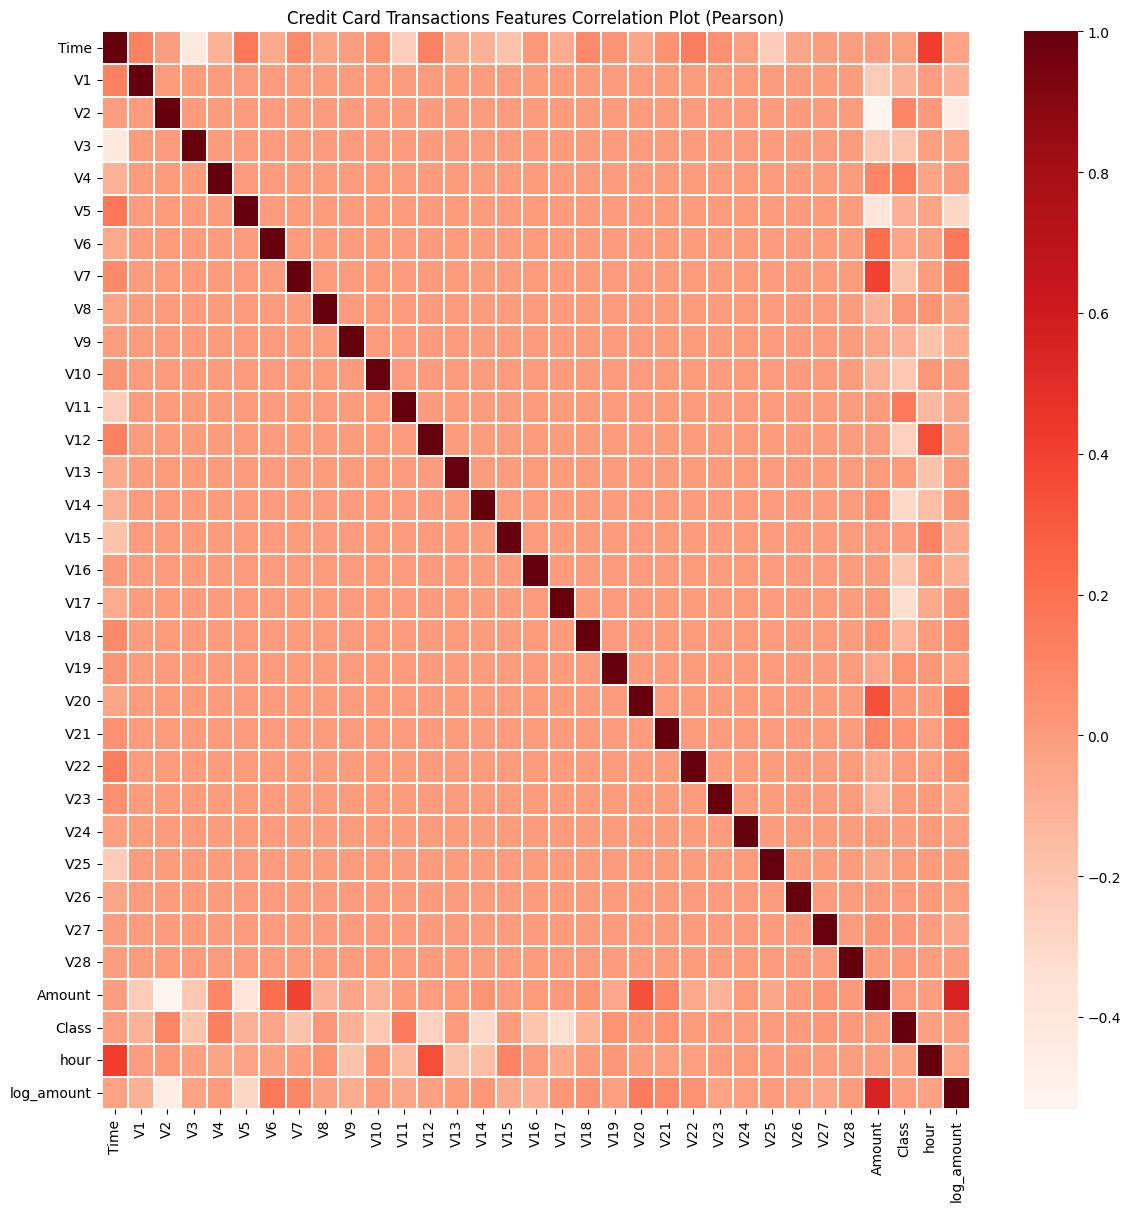

In [11]:
plt.figure(figsize=(14, 14))
plt.title("Credit Card Transactions Features Correlation Plot (Pearson)")
corr = df.corr()
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, linewidths=0.1, cmap="Reds")
plt.show()


予想どおり、V1〜V28 の特徴量間には顕著な相関は見られない。一方で、Time とは V3 が弱い逆相関、Amount とは V7 と V20 が正相関、V2 と V5 が逆相関の傾向を示す。相関は小さくても、後のモデル化で特徴量の寄与に違いが出ることがあるため、散布図で分布の形を確かめる。


相関係数は線形関係の強さを数値で示すが、クラスごとの分布差は反映しにくい。例えば、全体としては弱い相関でも、クラスごとに傾きが違う場合がある。そこで、Class（不正/正常）ごとに色分けし、回帰直線を重ねて傾向を確認する。まずは Amount と正の相関がある V20 と V7 を確認する。


In [ ]:
sns.lmplot(x="V20", y="Amount", data=df, hue="Class", fit_reg=True, scatter_kws={"s": 2})
sns.lmplot(x="V7", y="Amount", data=df, hue="Class", fit_reg=True, scatter_kws={"s": 2})
plt.show()


散布図の各点は1件の取引を表し、横軸がV20（またはV7）、縦軸がAmountである。青は正常（Class=0）、橙は不正（Class=1）で、線は各クラスの回帰直線を示す。両クラスとも右上がりのため、V20/V7が大きいほどAmountが大きくなる傾向（正の相関）がある。一方で、橙の直線は傾きが小さく、同じV20/V7でも不正取引のAmountは増え方が緩いことが読み取れる。


In [ ]:
sns.lmplot(x="V2", y="Amount", data=df, hue="Class", fit_reg=True, scatter_kws={"s": 2})
sns.lmplot(x="V5", y="Amount", data=df, hue="Class", fit_reg=True, scatter_kws={"s": 2})
plt.show()


散布図の各点は1件の取引を表し、横軸がV2（またはV5）、縦軸がAmountである。青は正常（Class=0）、橙は不正（Class=1）で、線は各クラスの回帰直線を示す。両クラスとも右下がりのため、V2/V5が大きいほどAmountが小さくなる傾向（逆相関）がある。橙の直線は傾きが緩やかで、不正取引ではAmountの減り方が小さいことが分かる。


### 特徴量の密度プロット
各特徴量の分布を Class ごとに重ねて描画することで、分布の形の違いを確認する。分布が大きく分離している特徴量は、モデルがクラス判定に利用しやすい。一方で、分布が大きく重なる特徴量は単独では判別力が低い可能性がある。


<Figure size 640x480 with 0 Axes>

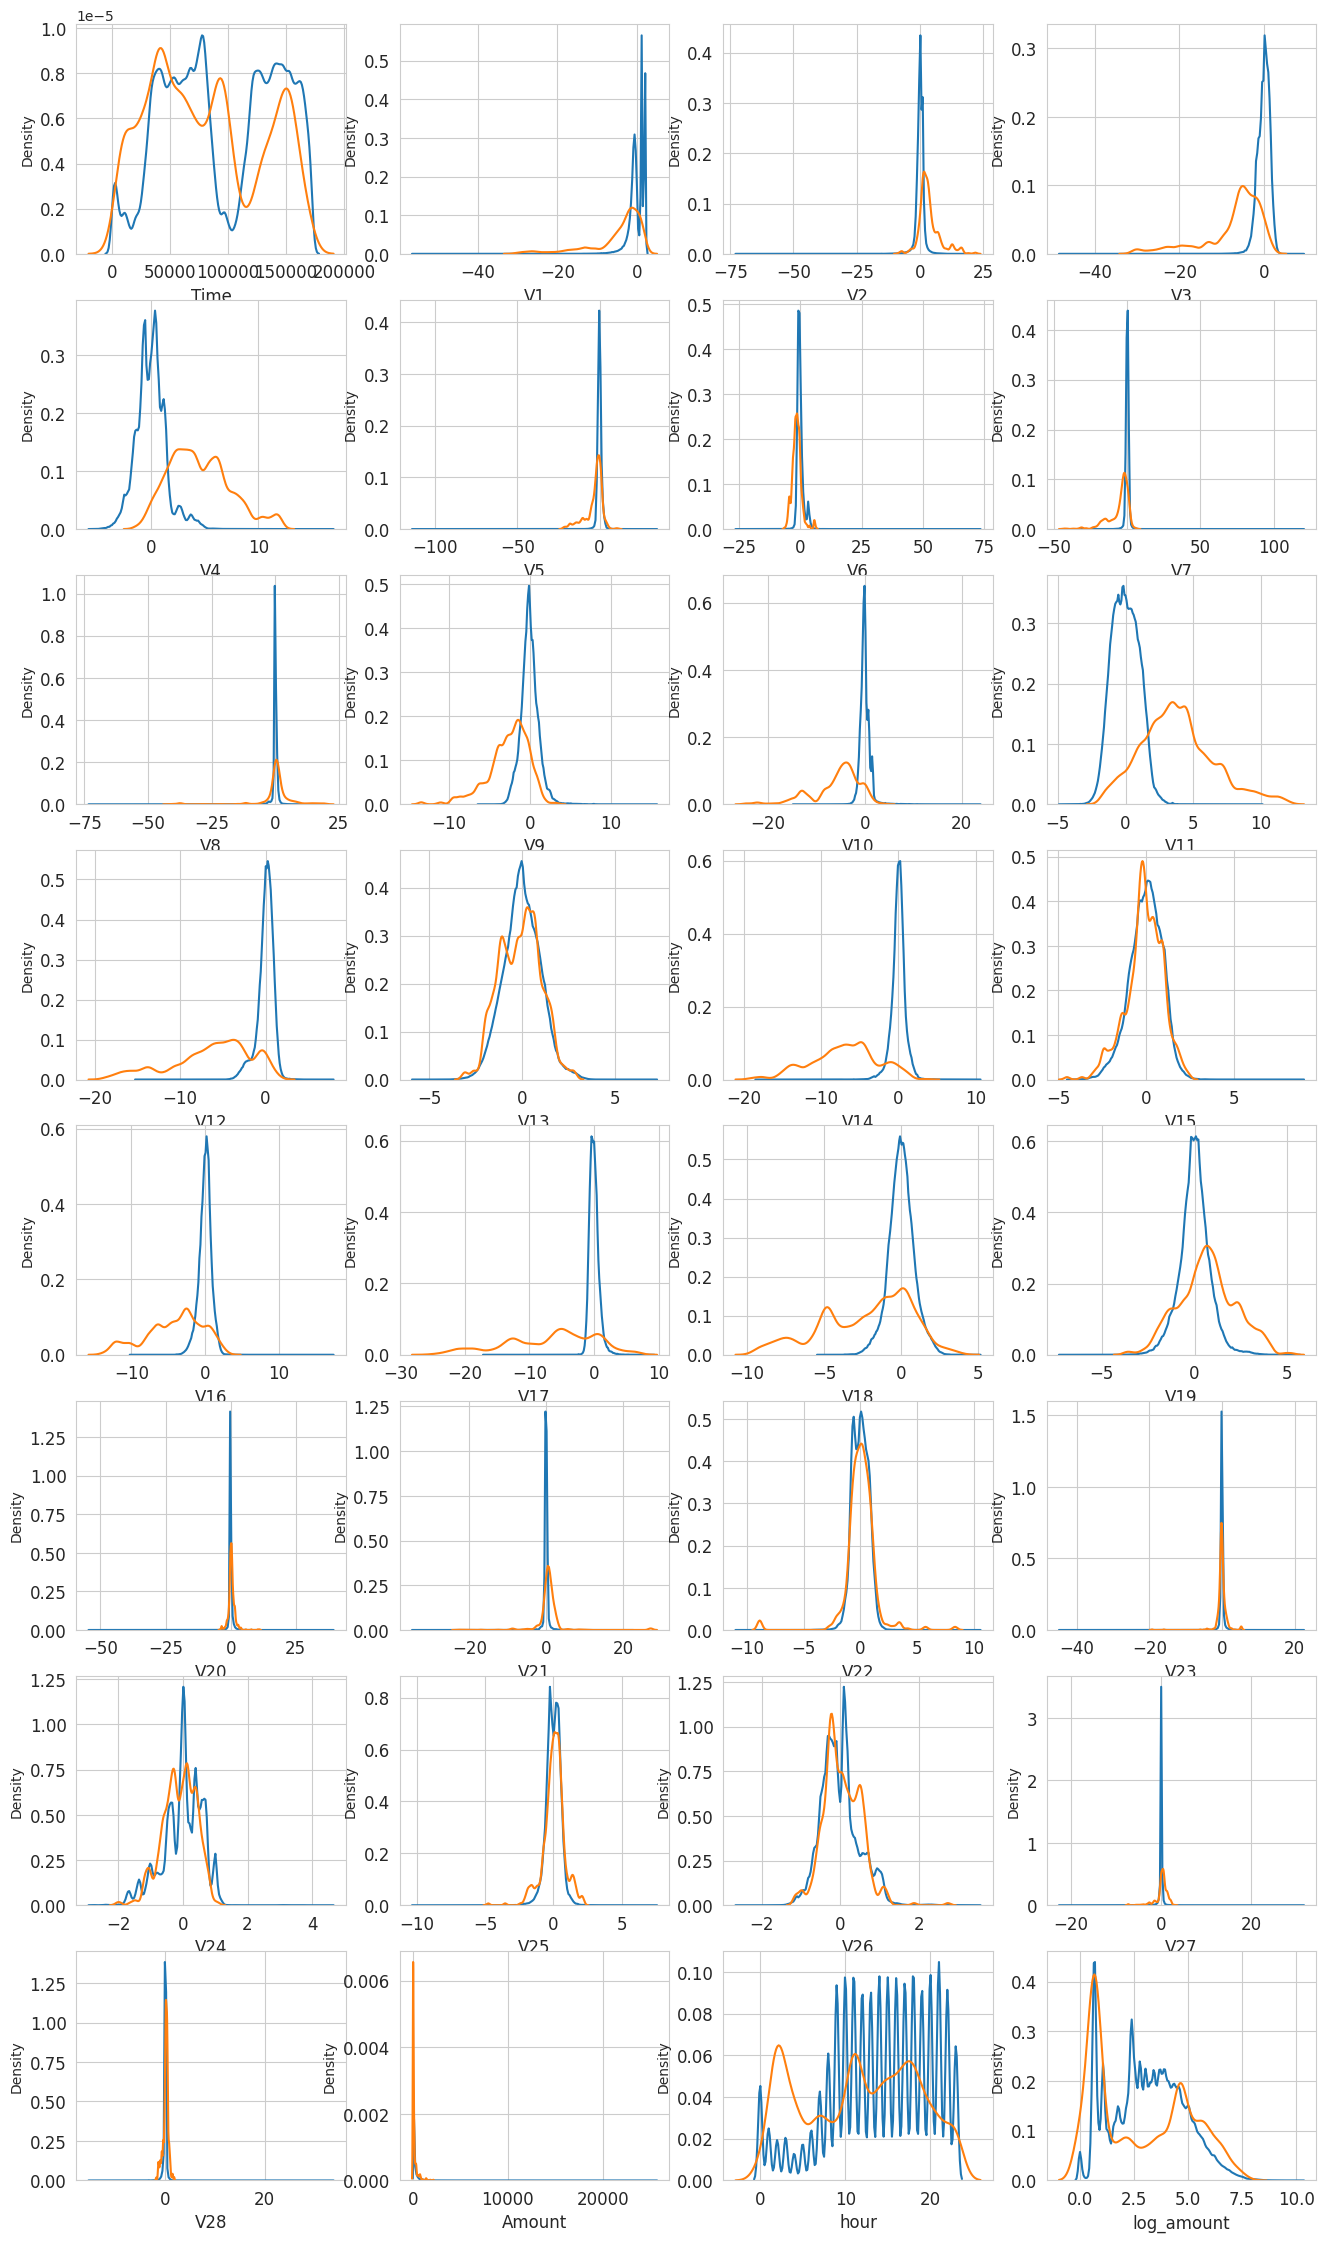

In [17]:
var = [c for c in df.columns if c != "Class"]

i = 0
t0 = df.loc[df["Class"] == 0]
t1 = df.loc[df["Class"] == 1]

sns.set_style("whitegrid")
plt.figure()
fig, ax = plt.subplots(8, 4, figsize=(16, 28))

for feature in var:
    i += 1
    plt.subplot(8, 4, i)
    sns.kdeplot(t0[feature], bw_adjust=0.5, label="Class = 0")
    sns.kdeplot(t1[feature], bw_adjust=0.5, label="Class = 1")
    plt.xlabel(feature, fontsize=12)
    plt.tick_params(axis="both", which="major", labelsize=12)
plt.show()


密度プロットを見るときは、(1) 2本の曲線がどれだけ重なるか、(2) ピークの位置と高さ、(3) 尾の長さ（裾の広がり）に着目する。

一部の特徴量では Class の2値に対して分布の選別性が良く、V4、V11 は Class の値 0 と 1 の分布が明確に分離している。ここでの分離は、Class=0 と Class=1 の曲線の重なりが小さく、ピーク位置や分布の形が明確にずれている状態を指す。分離が大きいほど、その特徴量単体でクラス判定に寄与しやすい。V12、V14、V18 は部分的に分離され、V1、V2、V3、V10 はかなり異なるプロファイルを持つ。『異なるプロファイル』とは、平均付近の位置や分布の左右の広がりが異なることで、同じ値が現れやすい領域がクラスで変わることを意味する。一方、V25、V26、V28 は Class の2値で類似したプロファイルであり、単独では判別力が小さい可能性がある。

全体として、いくつかの例外（Time と Amount）を除き、正常取引（Class = 0）の特徴量分布は 0 を中心に端で長い尾を持つ場合がある。一方で、不正取引（Class = 1）は歪んだ（非対称な）分布を示す。歪みが大きい特徴量では、極端な値が不正側に集まりやすい傾向があるため、分布の裾にも注意して見るとよい。

## 実験内容
本節では、不正検知のベースラインとして3つのモデルを比較する。評価は主にPR-AUCを用い、ROC-AUCと混同行列で補助的に確認する。


### 予測変数と目的変数の定義
目的変数は Class（不正=1, 正常=0）。それ以外を予測変数として使う。


In [ ]:
target = "Class"
predictors = [c for c in df.columns if c != target]


### 学習・検証・テストへの分割
クラス不均衡の影響を抑えるため、stratifyでクラス比率を保ったまま分割する。比率が崩れると、学習や評価が偏り、検証で不正がほとんど出ない（あるいは過剰に出る）などの状況が起き、指標が不安定になる。


In [ ]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.2
VALID_SIZE = 0.2

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df[target],
)
train_df, valid_df = train_test_split(
    train_df,
    test_size=VALID_SIZE,
    random_state=RANDOM_STATE,
    stratify=train_df[target],
)


### 実験1〜3：3モデルの学習と評価
- LogisticRegression（ベースライン。線形モデルで学習が速く、結果の解釈がしやすい。非線形関係は捉えにくい）
- RandomForestClassifier（非線形を捉えやすく、過学習に比較的強い。特徴量重要度が得られる。モデルが大きくなりやすい）
- GradientBoostingClassifier（勾配ブースティングの基本形。精度と計算量のバランスが取りやすい。パラメータ調整に敏感）


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "LogisticRegression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000, class_weight="balanced"),
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight="balanced_subsample",
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

results = []
proba_map = {}

for name, model in models.items():
    model.fit(train_df[predictors], train_df[target])
    proba = model.predict_proba(valid_df[predictors])[:, 1]
    results.append({
        "model": name,
        "roc_auc": roc_auc_score(valid_df[target], proba),
        "pr_auc": average_precision_score(valid_df[target], proba),
    })
    proba_map[name] = proba

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df


### ROC/PR曲線の可視化
曲線の位置が上側（ROC）・右上側（PR）に寄るほど良い。PR曲線は不正クラスの識別能力が高いほど面積が大きくなる。


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for name, proba in proba_map.items():
    RocCurveDisplay.from_predictions(valid_df[target], proba, ax=axes[0], name=name)
    PrecisionRecallDisplay.from_predictions(valid_df[target], proba, ax=axes[1], name=name)

axes[0].set_title("ROC Curve (Valid)")
axes[1].set_title("PR Curve (Valid)")
plt.show()


### 混同行列（PR-AUC上位モデル）
PR-AUCが最も高いモデルを暫定採用候補として、誤検知・見逃しのバランスを確認する。


In [ ]:
from sklearn.metrics import confusion_matrix

best_name = results_df.iloc[0]["model"]
best_proba = proba_map[best_name]
best_preds = (best_proba >= 0.5).astype(int)

cm = confusion_matrix(valid_df[target], best_preds)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"],
    annot=True,
    fmt="d",
    ax=ax,
    linewidths=0.2,
    linecolor="Darkblue",
    cmap="Blues",
)
ax.set_title(f"Confusion Matrix (Valid) - {best_name}")
plt.show()


## 評価・可視化・考察
評価はPR-AUCを優先して比較し、ROC-AUCは補助指標として確認する。PR-AUCが最も高いモデルを採用候補とし、ROC/PR曲線の形から安定性を確認する。

混同行列では、偽陰性（不正を見逃す）と偽陽性（正常を誤検知する）のバランスを確認する。業務上のコストが大きい誤り（通常は偽陰性）を優先的に減らしたい場合は、閾値を0.5から調整する。

判断としては、PR-AUC上位のモデルを第一候補とし、偽陰性が許容範囲に収まることを確認した上で採用する。


### モデル別の評価（検証データ）
- RandomForest：PR-AUCが0.81と最も高く、不正検知の観点で最有力。ROC-AUCは0.94で、全体の識別も十分。混同行列では偽陰性22・偽陽性3と、見逃しはあるが許容範囲に近い。
- LogisticRegression：ROC-AUCは0.98と高いが、PR-AUCが0.68と低めで不正クラスの識別が弱い。線形モデルのため、非線形な関係を拾い切れない可能性がある。
- GradientBoosting：ROC-AUC 0.79、PR-AUC 0.54で3モデル中最も低く、今回の設定では有効性が限定的。パラメータ調整や特徴量工夫が必要。

